# Report 1 — Preliminary Analysis, Descriptive Statistics, and Visualizations
## Selective Attention Game Validation Study

**Study design:** 2 × 2 Mixed Factorial  
**Between-subjects factor:** Target Load (Single vs. Multiple)  
**Within-subjects factor:** Modality (Lab vs. Game)  
**N = 37** (Group A: Single Target, n = 21, IDs 1–21 | Group B: Multiple Target, n = 16, IDs 22–37)  
**Dependent variables:** Reaction Time (RT, seconds) · Accuracy (proportion 0–1)

---

### Research Questions
| RQ | Question |
|---|---|
| RQ1 — Concurrent Validity | Is there a significant positive correlation between Game and Lab performance? |
| RQ2 — Load Effect | Is performance significantly worse in the Multiple Target condition? |
| RQ3 — Modality Effect | Does the gamified interface significantly alter performance vs. the lab? |
| RQ4 — Level Effect | Does performance change across game levels (learning / fatigue)? |

---

### Notebook Structure
1. Imports and Setup  
2. Data Loading and Inspection  
3. Data Cleaning  
4. Descriptive Statistics (M, SD across all 4 cells)  
5. Visualizations  
   - 5.1 RT Distributions per Condition (Histogram + KDE)  
   - 5.2 Accuracy Distributions per Condition (Histogram + KDE)  
   - 5.3 Group Means with 95% CI (Bar Chart)  
   - 5.4 Lab vs. Game per Participant (Scatter — RQ1)  
6. Normality Checks (Shapiro-Wilk)  
7. Inferential Tests  
   - 7.1 Load Effect — Independent Samples t-test (RQ2)  
   - 7.2 Modality Effect — Paired Samples t-test (RQ3)  
   - 7.3 Concurrent Validity — Pearson r (RQ1)  
   - 7.4 Level Effect — Pearson r on Level vs. RT (RQ4)  
8. Summary Table of All Test Results

## 1. Imports and Setup

In [2]:
import os, re, glob, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats
from scipy.stats import pearsonr, shapiro

warnings.filterwarnings('ignore')

# ── visual style ─────────────────────────────────────────────────
sns.set_theme(style='whitegrid', font_scale=1.15)
PALETTE      = {'lab': '#4C72B0', 'game': '#DD8452'}   # blue=lab, orange=game
LOAD_PALETTE = {'single': '#55A868', 'multiple': '#C44E52'}  # green=single, red=multiple
plt.rcParams.update({'figure.dpi': 110, 'figure.facecolor': 'white'})

# ── Bonferroni-corrected significance threshold ───────────────────
# 4 t-tests + 4 correlations -> alpha / 4 per family
ALPHA_CORR = 0.05 / 4   # = 0.0125

print(f'Bonferroni-corrected alpha = {ALPHA_CORR}')
print('Setup complete.')

Bonferroni-corrected alpha = 0.0125
Setup complete.


## 2. Data Loading

### 2.1 Helper Functions

In [3]:
def participant_id_from_filename(filepath):
    """Extract leading integer from filename as participant ID."""
    fname = os.path.basename(filepath)
    m = re.match(r'^(\d+)', fname)
    if m:
        return int(m.group(1))
    return None

def parse_first_float(val):
    """Extract the first numeric value from a stringified list e.g. '[0.45, 0.89]'."""    
    try:
        s = str(val).strip()
        nums = re.findall(r'[-+]?\d*\.?\d+', s)
        return float(nums[0]) if nums else np.nan
    except Exception:
        return np.nan

def parse_str_list(val):
    """Convert a stringified Python list to an actual list of strings."""    
    try:
        import ast
        return ast.literal_eval(str(val))
    except Exception:
        return []

def count_hit_positions(val):
    """Count number of (x,y) tuples in HitPositions string."""    
    try:
        return str(val).count('(')
    except Exception:
        return 0

def norm_col(name):
    """Normalise column name: lowercase, strip punctuation/spaces."""    
    return re.sub(r'[^a-z0-9]', '', str(name).lower())

print('Helper functions defined.')

Helper functions defined.


### 2.2 Lab Data Loader (PsychoPy CSV)

In [4]:
# ═══════════════════════════════════════════════════════════════════
# single/lab & multiple/lab  — PsychoPy CSV
#
# Participant ID: extracted from filename prefix (e.g. '7_task.csv' → 7)
#
# Timing:
#   trial.started, square.started → absolute (wrt expStart)
#   mouse.time                    → relative (wrt trial.started)
# RT = mouse.time[0] − (square.started − trial.started)
#
# Accuracy:
#   Single   : 1 if 'target' is in mouse.clicked_name (exact object name)
#   Multiple : len(clicked ∩ {'target_0'..'target_4'}) / 5
#   target_col stores the display colour — saved as target_color,
#   NOT used for accuracy scoring.
# ═══════════════════════════════════════════════════════════════════
def load_psychopy(folder, target_load):
    rows = []
    for f in sorted(glob.glob(os.path.join(folder, '*.csv'))):
        try:
            df = pd.read_csv(f, low_memory=False)
            df.columns = df.columns.str.strip().str.lstrip('\ufeff')
            df = df[df['trials.thisN'].notna()].copy()
            if df.empty:
                continue

            pid      = participant_id_from_filename(f)
            t_start  = pd.to_numeric(df['trial.started'],  errors='coerce')
            sq_start = pd.to_numeric(df['square.started'], errors='coerce')
            sq_rel   = sq_start - t_start          # pre-stimulus delay
            RT       = df['mouse.time'].apply(parse_first_float) - sq_rel

            clicked      = df['mouse.clicked_name'].apply(parse_str_list)
            target_color = df['target_col'].astype(str).str.strip().str.lower()

            MULTI_TARGETS = {f'target_{i}' for i in range(5)}

            def _acc(idx):
                c = clicked.iloc[idx]
                if not c:
                    return 0.0
                c_norm = [str(x).strip().lower() for x in c]
                if target_load == 'single':
                    # correct object is named exactly 'target'
                    return 1.0 if 'target' in c_norm else 0.0
                else:
                    # correct objects are 'target_0' .. 'target_4'
                    n_correct = len(set(c_norm) & MULTI_TARGETS)
                    return n_correct / 5.0

            accuracy = np.array([_acc(i) for i in range(len(df))])

            out = pd.DataFrame({
                'participant' : pid,
                'target_load' : target_load,
                'modality'    : 'lab',
                'trial_num'   : pd.to_numeric(df['trials.thisN'], errors='coerce').values,
                'RT'          : RT.values,
                'accuracy'    : accuracy,
                'n_clicks'    : clicked.apply(len).values,
                'target_color': target_color.values,
            })
            rows.append(out)
        except Exception as e:
            print(f'  WARNING  {target_load}/lab  {os.path.basename(f)}: {e}')
    result = pd.concat(rows, ignore_index=True) if rows else pd.DataFrame()
    if not result.empty:
        print(f'  Loaded {len(result):>5} trials from {folder}  '
              f'({result.participant.nunique()} participants)')
    return result

print('Lab loader defined.')
print('RT  : mouse.time[0] - (square.started - trial.started)')
print('Acc (single)   : 1 if "target" in clicked_names else 0')
print('Acc (multiple) : |clicked ∩ {target_0..target_4}| / 5')


Lab loader defined.
RT  : mouse.time[0] - (square.started - trial.started)
Acc (single)   : 1 if "target" in clicked_names else 0
Acc (multiple) : |clicked ∩ {target_0..target_4}| / 5


### 2.3 Game Data Loader (Game CSV)

In [5]:
# ═══════════════════════════════════════════════════════════════════
# single/phone & multiple/phone  — Game CSV
#
# Participant ID: extracted from filename prefix (e.g. '7_game.csv' → 7)
#
# Fields used:
#   InitialResponseTime(ms) ÷ 1000  → RT in seconds
#   SuccessRate(%)          ÷ 100   → accuracy 0-1
#   HitPositions(x,y)               → n_clicks (count tuples)
#   Level                           → trial_num
# ═══════════════════════════════════════════════════════════════════
def load_phone(folder, target_load):
    rows = []
    for f in sorted(glob.glob(os.path.join(folder, '*.csv'))):
        try:
            df = pd.read_csv(f, low_memory=False)
            df.columns = df.columns.str.strip().str.lstrip('\ufeff')
            if df.empty:
                continue

            pid = participant_id_from_filename(f)

            def norm(s): return re.sub(r'[^a-z0-9]', '', s.lower())
            col_map = {norm(c): c for c in df.columns}
            def get(*cands):
                for c in cands:
                    if norm(c) in col_map: return col_map[norm(c)]
                return None

            lvl_col = get('Level', 'level')
            rt_col  = get('InitialResponseTime(ms)', 'InitialResponseTimems',
                          'initialresponsetime')
            acc_col = get('SuccessRate(%)', 'SuccessRate', 'successrate')
            hit_col = get('HitPositions(x,y)', 'HitPositions', 'hitpositions')

            out = pd.DataFrame()
            out['participant']  = [pid] * len(df)
            out['target_load']  = target_load
            out['modality']     = 'game'
            out['trial_num']    = pd.to_numeric(df[lvl_col],  errors='coerce') if lvl_col  else np.nan
            out['RT']           = pd.to_numeric(df[rt_col],   errors='coerce') / 1000.0    if rt_col   else np.nan
            out['accuracy']     = pd.to_numeric(df[acc_col],  errors='coerce') / 100.0     if acc_col  else np.nan
            out['n_clicks']     = df[hit_col].apply(count_hit_positions)                   if hit_col  else np.nan
            out['target_color'] = ''   # not recorded in game data
            rows.append(out)
        except Exception as e:
            print(f'  WARNING  {target_load}/phone  {os.path.basename(f)}: {e}')
    result = pd.concat(rows, ignore_index=True) if rows else pd.DataFrame()
    if not result.empty:
        print(f'  Loaded {len(result):>5} rows   from {folder}  '
              f'({result.participant.nunique()} participants)')
    return result

print('Phone/game loader defined.')


Phone/game loader defined.


### 2.4 Load All Four Conditions

In [6]:
# ── Set BASE_DIR to the folder that contains your 'single' and 'multiple' subfolders ──
# Example: if your data lives at /home/user/data/single/lab, set BASE_DIR = '/home/user/data'
BASE_DIR = '.'   # change this if needed

FOLDERS = {
    ('single',   'lab'):  os.path.join(BASE_DIR, 'single',   'lab'),
    ('single',   'game'): os.path.join(BASE_DIR, 'single',   'phone'),
    ('multiple', 'lab'):  os.path.join(BASE_DIR, 'multiple', 'lab'),
    ('multiple', 'game'): os.path.join(BASE_DIR, 'multiple', 'phone'),
}

print('Loading data...')
parts = []
for (load, mod), folder in FOLDERS.items():
    if not os.path.isdir(folder):
        print(f'  FOLDER NOT FOUND: {folder}')
        continue
    if mod == 'lab':
        parts.append(load_psychopy(folder, load))
    else:
        parts.append(load_phone(folder, load))

if not parts:
    raise RuntimeError('No data loaded. Check that BASE_DIR and folder names are correct.')

trials = pd.concat(parts, ignore_index=True)

print()
print(f'Total rows  : {len(trials)}')
print(f'Participants: {trials.participant.nunique()}')
print()
print(trials.groupby(['target_load', 'modality'])[['participant']].nunique()
      .rename(columns={'participant': 'N_participants'}))

Loading data...
  Loaded   315 trials from ./single/lab  (21 participants)
  Loaded   351 rows   from ./single/phone  (21 participants)
  Loaded   240 trials from ./multiple/lab  (16 participants)
  Loaded   195 rows   from ./multiple/phone  (16 participants)

Total rows  : 1101
Participants: 37

                      N_participants
target_load modality                
multiple    game                  16
            lab                   16
single      game                  21
            lab                   21


### 2.5 Data Audit

Check participant ID counts per folder. If any ID appears more than once in a folder, it means multiple files exist for the same participant (e.g. a re-run or separate session file). Duplicates will be averaged together at the participant-level aggregation step, so they do not break the analysis, but it is good practice to know they exist.

In [7]:
print('Participant ID counts per condition')
print('-' * 50)
for (load, mod), grp in trials.groupby(['target_load', 'modality']):
    id_counts = grp.groupby('participant')['trial_num'].count()
    n_ids     = len(id_counts)
    n_rows    = len(grp)
    print(f'  {load}/{mod}: {n_ids} unique participants, {n_rows} rows total')

print()
print('Expected: single/lab=21, single/game=21, multiple/lab=16, multiple/game=16')
print()

# flag any duplicate filenames (participants with unexpectedly high row counts)
print('Participants with row count > 2x the group median (possible duplicate files):')
flagged = False
for (load, mod), grp in trials.groupby(['target_load', 'modality']):
    counts = grp.groupby('participant')['trial_num'].count()
    threshold = counts.median() * 2
    outliers  = counts[counts > threshold]
    if not outliers.empty:
        for pid, cnt in outliers.items():
            print(f'  {load}/{mod}  participant {pid}: {cnt} rows  (median={counts.median():.0f})')
        flagged = True
if not flagged:
    print('  None found.')

Participant ID counts per condition
--------------------------------------------------
  multiple/game: 16 unique participants, 195 rows total
  multiple/lab: 16 unique participants, 240 rows total
  single/game: 21 unique participants, 351 rows total
  single/lab: 21 unique participants, 315 rows total

Expected: single/lab=21, single/game=21, multiple/lab=16, multiple/game=16

Participants with row count > 2x the group median (possible duplicate files):
  single/game  participant 6: 39 rows  (median=15)


## 3. Data Cleaning

Three cleaning steps are applied before any analysis:

1. **RT bounds filter** — remove trials with RT < 0.1 s (faster than human visual processing) or RT > 30 s (participant likely disengaged). Applied to lab trial-level data; game rows with extreme values are also removed.
2. **Accuracy clip** — game SuccessRate can occasionally round above 100% due to floating-point arithmetic in the game engine. Accuracy is clipped to [0, 1].
3. **Participant-level aggregation** — all statistical tests operate on **participant means** (one RT mean and one accuracy mean per participant per condition cell), not on raw trial-level rows. This prevents pseudo-replication.

In [8]:
n_before = len(trials)

# RT bounds filter
trials = trials[(trials.RT >= 0.1) & (trials.RT <= 30.0)].copy()

# Accuracy clip (already applied in loader, but enforce here for safety)
trials['accuracy'] = trials['accuracy'].clip(0.0, 1.0)

n_after = len(trials)
print(f'Rows before cleaning : {n_before}')
print(f'Rows after  cleaning : {n_after}  ({n_before - n_after} removed)')
print()

# ── participant-level means ───────────────────────────────────────
ppt_means = (
    trials
    .groupby(['participant', 'target_load', 'modality'])
    .agg(RT_mean  = ('RT',       'mean'),
         RT_sd    = ('RT',       'std'),
         Acc_mean = ('accuracy', 'mean'),
         Acc_sd   = ('accuracy', 'std'),
         n_trials = ('RT',       'count'))
    .reset_index()
)

print(f'Participant-level rows: {len(ppt_means)}')
print()
print(ppt_means.groupby(['target_load', 'modality'])[['participant']].nunique()
      .rename(columns={'participant': 'N'}))

Rows before cleaning : 1101
Rows after  cleaning : 1082  (19 removed)

Participant-level rows: 74

                       N
target_load modality    
multiple    game      16
            lab       16
single      game      21
            lab       21


## 4. Descriptive Statistics

Mean (M) and Standard Deviation (SD) for RT (seconds) and Accuracy (proportion 0–1) across all four cells of the design. All values are computed from participant-level means.

In [9]:
desc = (
    ppt_means
    .groupby(['target_load', 'modality'])
    .agg(
        N        = ('RT_mean',  'count'),
        RT_M     = ('RT_mean',  'mean'),
        RT_SD    = ('RT_mean',  'std'),
        RT_Med   = ('RT_mean',  'median'),
        RT_Min   = ('RT_mean',  'min'),
        RT_Max   = ('RT_mean',  'max'),
        Acc_M    = ('Acc_mean', 'mean'),
        Acc_SD   = ('Acc_mean', 'std'),
        Acc_Med  = ('Acc_mean', 'median'),
    )
    .round(3)
)

print('=' * 70)
print('DESCRIPTIVE STATISTICS  (participant-level means)')
print('RT in seconds | Accuracy as proportion 0-1')
print('=' * 70)
print(desc.to_string())
print()
print('Cells: single/lab (Group A, n=21), single/game (Group A, n=21),')
print('       multiple/lab (Group B, n=16), multiple/game (Group B, n=16)')

DESCRIPTIVE STATISTICS  (participant-level means)
RT in seconds | Accuracy as proportion 0-1
                       N   RT_M  RT_SD  RT_Med  RT_Min  RT_Max  Acc_M  Acc_SD  Acc_Med
target_load modality                                                                  
multiple    game      16  1.856  0.507   1.719   1.136   3.120  0.964   0.025    0.963
            lab       16  1.505  0.268   1.428   1.186   2.023  0.951   0.135    0.993
single      game      21  3.104  0.625   2.923   2.258   4.683  0.983   0.028    1.000
            lab       21  1.495  0.225   1.471   1.093   2.223  1.000   0.000    1.000

Cells: single/lab (Group A, n=21), single/game (Group A, n=21),
       multiple/lab (Group B, n=16), multiple/game (Group B, n=16)


## 5. Visualizations

All plots use participant-level means. Colour coding is consistent throughout:
- **Blue (#4C72B0) = Lab** | **Orange (#DD8452) = Game**
- **Green (#55A868) = Single Target** | **Red (#C44E52) = Multiple Target**

### 5.1 RT Distributions per Condition

Histograms with KDE overlay and a dashed median line, one panel per condition cell.
RT data is typically right-skewed (long tail of slow trials). Inspecting distributions
before running parametric tests helps identify skew, multimodality, and outliers.

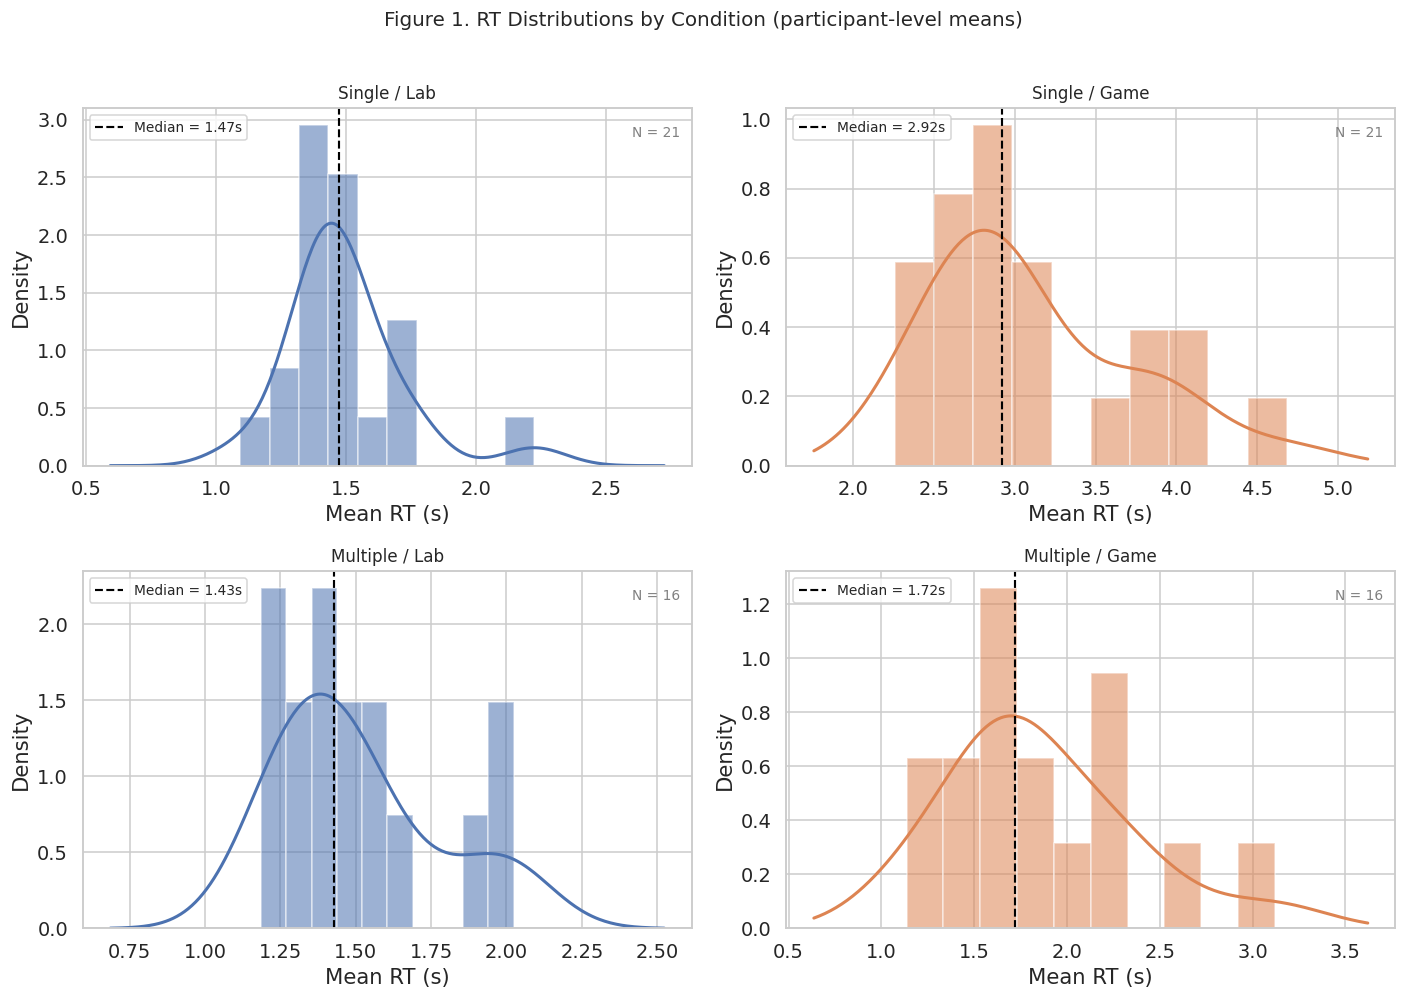

Figure 1 saved.


In [29]:
conditions = [
    ('single',   'lab',  'Single / Lab',   PALETTE['lab'],  0, 0),
    ('single',   'game', 'Single / Game',  PALETTE['game'], 0, 1),
    ('multiple', 'lab',  'Multiple / Lab', PALETTE['lab'],  1, 0),
    ('multiple', 'game', 'Multiple / Game',PALETTE['game'], 1, 1),
]

fig, axes = plt.subplots(2, 2, figsize=(13, 9))
fig.suptitle('Figure 1. RT Distributions by Condition (participant-level means)',
             fontsize=13, y=1.01)

for load, mod, title, color, r, c in conditions:
    ax  = axes[r][c]
    sub = ppt_means[(ppt_means.target_load == load) & (ppt_means.modality == mod)]['RT_mean'].dropna()

    if len(sub) < 3:
        ax.set_title(title + ' (insufficient data)'); continue

    ax.hist(sub, bins=10, color=color, alpha=0.55, edgecolor='white', density=True)

    # KDE — only possible when there is variance in the data
    if sub.std() > 0:
        from scipy.stats import gaussian_kde
        xs  = np.linspace(sub.min() - 0.5, sub.max() + 0.5, 300)
        kde = gaussian_kde(sub, bw_method='scott')
        ax.plot(xs, kde(xs), color=color, linewidth=2)

    med = sub.median()
    ax.axvline(med, color='black', linestyle='--', linewidth=1.4,
               label=f'Median = {med:.2f}s')

    ax.set_title(title, fontsize=11)
    ax.set_xlabel('Mean RT (s)')
    ax.set_ylabel('Density')
    ax.legend(fontsize=9)
    ax.text(0.98, 0.95, f'N = {len(sub)}', transform=ax.transAxes,
            ha='right', va='top', fontsize=9, color='grey')

plt.tight_layout()
plt.savefig('fig1_rt_distributions.png', bbox_inches='tight')
plt.show()
print('Figure 1 saved.')


### 5.2 Accuracy Distributions per Condition

Same layout as Figure 1 but for Accuracy. Accuracy in easy tasks often shows a
**ceiling effect** (left skew) — most participants cluster near 1.0. Ceiling effects
reduce between-person variance and can limit statistical power.

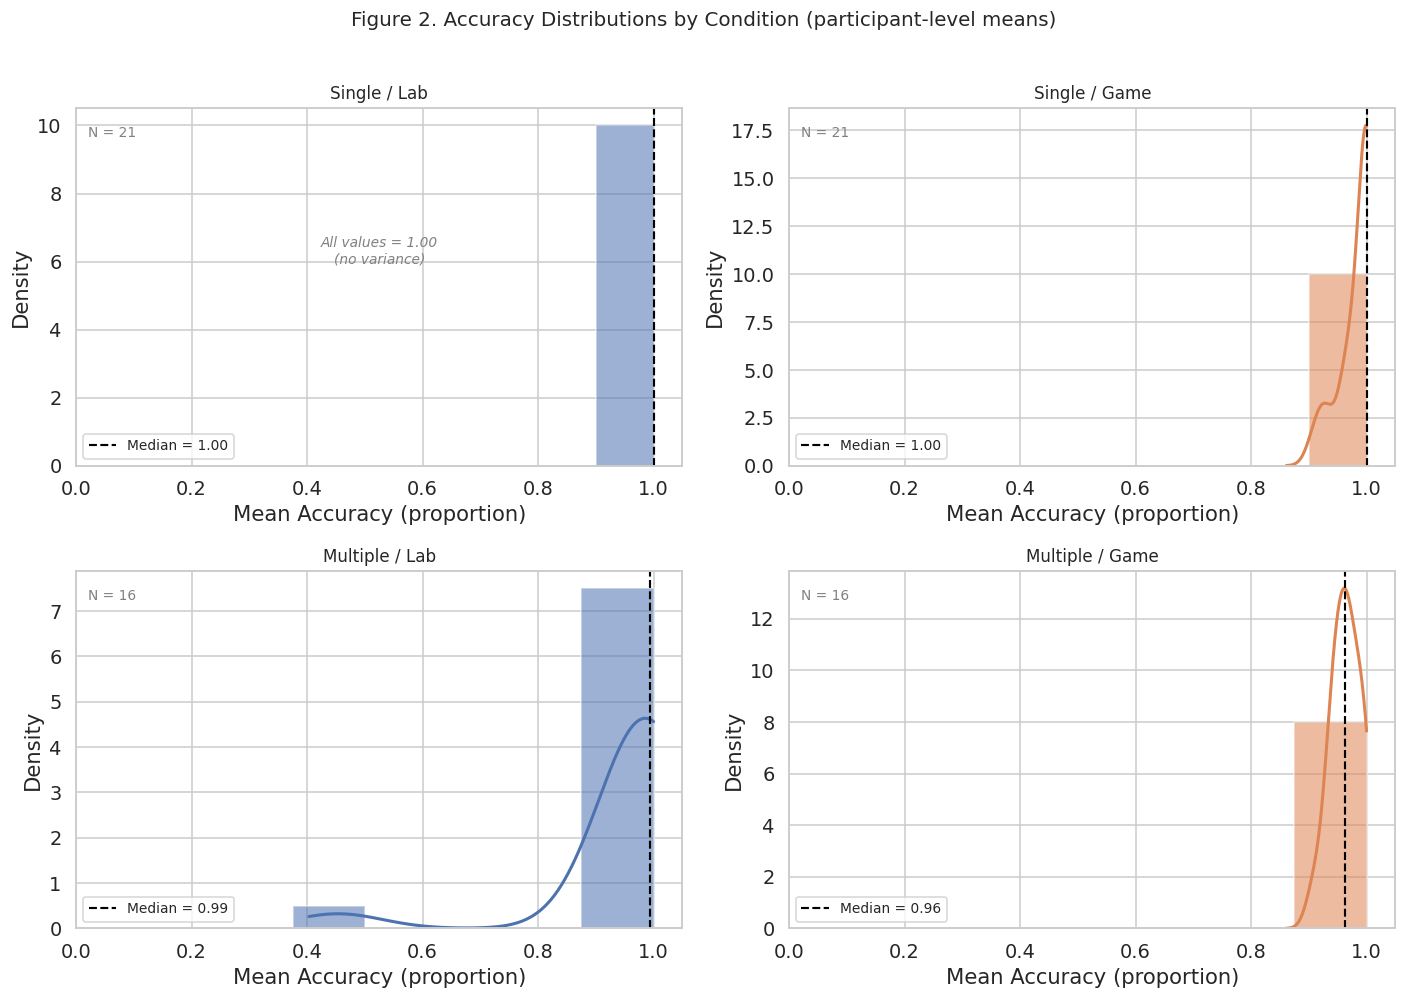

Figure 2 saved.


In [30]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
fig.suptitle('Figure 2. Accuracy Distributions by Condition (participant-level means)',
             fontsize=13, y=1.01)

for load, mod, title, color, r, c in conditions:
    ax  = axes[r][c]
    sub = ppt_means[(ppt_means.target_load == load) & (ppt_means.modality == mod)]['Acc_mean'].dropna()

    if len(sub) < 3:
        ax.set_title(title + ' (insufficient data)'); continue

    # use fewer bins if range is narrow (e.g. all values near 1.0)
    data_range = sub.max() - sub.min()
    n_bins = max(5, min(10, int(len(sub) / 2)))

    ax.hist(sub, bins=n_bins, color=color, alpha=0.55, edgecolor='white',
            density=True, range=(0, 1))

    # KDE — only possible when there is variance in the data
    # Zero variance occurs when all participants score identically (e.g. all 1.0)
    if sub.std() > 0 and data_range > 0:
        from scipy.stats import gaussian_kde
        xs  = np.linspace(max(sub.min() - 0.05, 0), min(sub.max() + 0.05, 1), 300)
        kde = gaussian_kde(sub, bw_method='scott')
        ax.plot(xs, kde(xs), color=color, linewidth=2)
    else:
        # annotate that all values are identical
        ax.text(0.5, 0.6, f'All values = {sub.iloc[0]:.2f}\n(no variance)',
                transform=ax.transAxes, ha='center', va='center',
                fontsize=9, color='grey', style='italic')

    med = sub.median()
    ax.axvline(med, color='black', linestyle='--', linewidth=1.4,
               label=f'Median = {med:.2f}')
    ax.set_xlim(0, 1.05)
    ax.set_title(title, fontsize=11)
    ax.set_xlabel('Mean Accuracy (proportion)')
    ax.set_ylabel('Density')
    ax.legend(fontsize=9)
    ax.text(0.02, 0.95, f'N = {len(sub)}', transform=ax.transAxes,
            ha='left', va='top', fontsize=9, color='grey')

plt.tight_layout()
plt.savefig('fig2_accuracy_distributions.png', bbox_inches='tight')
plt.show()
print('Figure 2 saved.')


### 5.3 Group Means with 95% Confidence Intervals

Bar charts of participant-level means with 95% CI error bars (seaborn default).
Left panel = RT, right panel = Accuracy.
This provides a compact visual summary of all four cells simultaneously and
allows a preliminary visual inspection of both the load effect (Single vs. Multiple)
and the modality effect (Lab vs. Game).

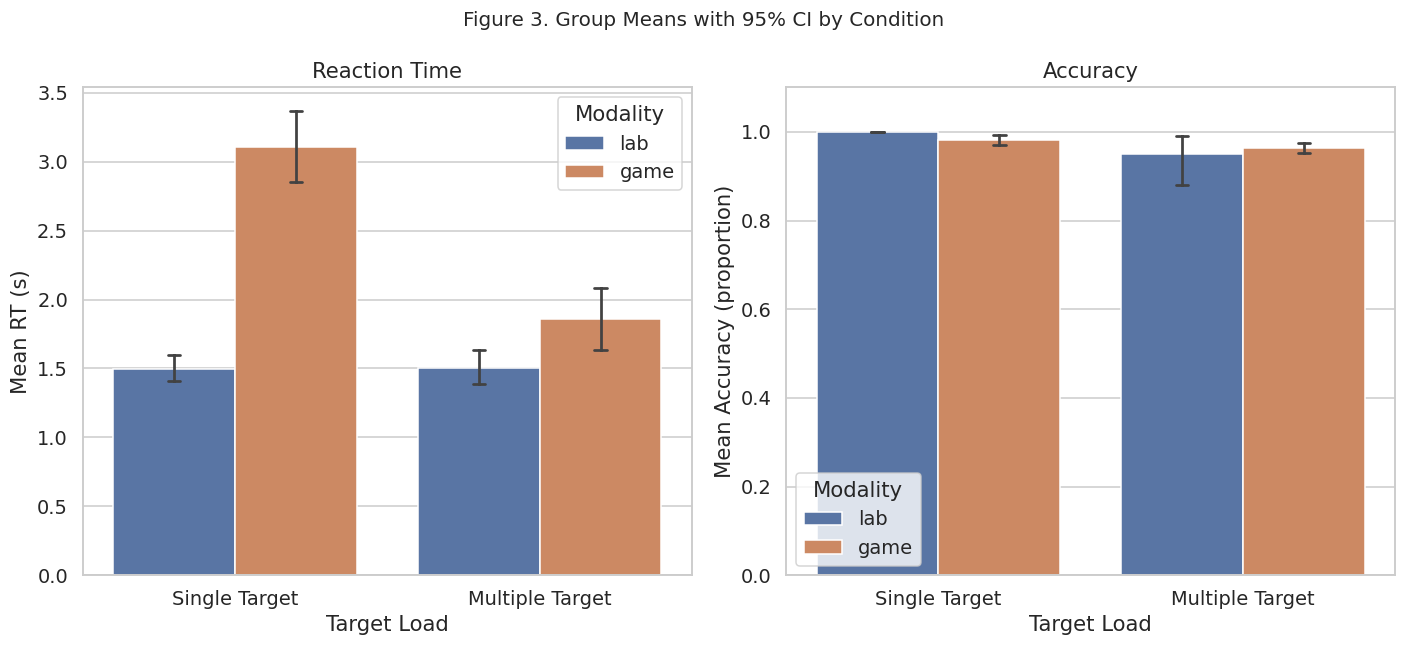

Figure 3 saved.


In [31]:
fig, axes = plt.subplots(1, 2, figsize=(13, 6))
fig.suptitle('Figure 3. Group Means with 95% CI by Condition', fontsize=13)

# RT
sns.barplot(data=ppt_means, x='target_load', y='RT_mean',
            hue='modality', palette=PALETTE,
            ci=95, capsize=0.08, errwidth=1.8,
            order=['single', 'multiple'],
            hue_order=['lab', 'game'],
            ax=axes[0])
axes[0].set_title('Reaction Time')
axes[0].set_xlabel('Target Load')
axes[0].set_ylabel('Mean RT (s)')
axes[0].set_xticklabels(['Single Target', 'Multiple Target'])
axes[0].legend(title='Modality')

# Accuracy
sns.barplot(data=ppt_means, x='target_load', y='Acc_mean',
            hue='modality', palette=PALETTE,
            ci=95, capsize=0.08, errwidth=1.8,
            order=['single', 'multiple'],
            hue_order=['lab', 'game'],
            ax=axes[1])
axes[1].set_title('Accuracy')
axes[1].set_xlabel('Target Load')
axes[1].set_ylabel('Mean Accuracy (proportion)')
axes[1].set_xticklabels(['Single Target', 'Multiple Target'])
axes[1].set_ylim(0, 1.1)
axes[1].legend(title='Modality')

plt.tight_layout()
plt.savefig('fig3_means_ci.png', bbox_inches='tight')
plt.show()
print('Figure 3 saved.')

### 5.4 Lab vs. Game per Participant — Scatter Plot (RQ1: Concurrent Validity)

Each point is one participant's mean score (Lab on x-axis, Game on y-axis).
A dashed regression line shows the direction of the linear relationship.
A positive slope indicates that participants who perform better in the lab
also perform better in the game — the core requirement for concurrent validity.
Panels are split by Target Load group and DV.

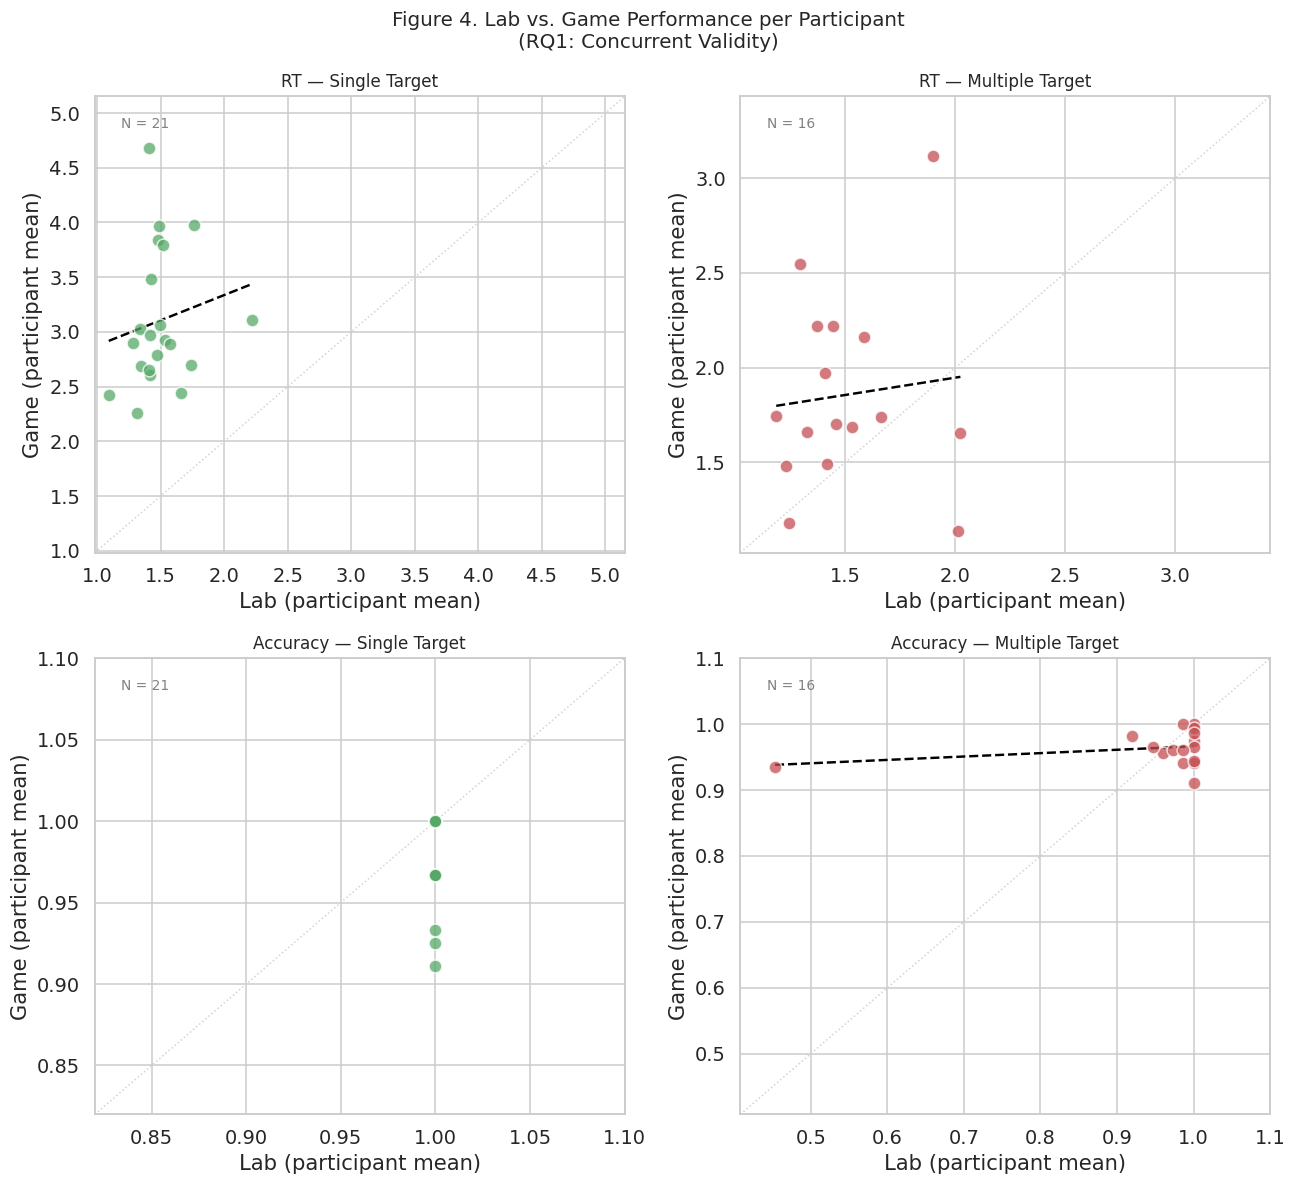

Figure 4 saved.


In [32]:
# pivot to wide format
ppt_wide = ppt_means.pivot_table(
    index=['participant', 'target_load'],
    columns='modality',
    values=['RT_mean', 'Acc_mean']
).reset_index()
ppt_wide.columns = ['_'.join(c).strip('_') for c in ppt_wide.columns]

pairs = [
    ('RT_mean_lab',  'RT_mean_game',  'single',   'RT — Single Target',    LOAD_PALETTE['single']),
    ('RT_mean_lab',  'RT_mean_game',  'multiple', 'RT — Multiple Target',  LOAD_PALETTE['multiple']),
    ('Acc_mean_lab', 'Acc_mean_game', 'single',   'Accuracy — Single Target',   LOAD_PALETTE['single']),
    ('Acc_mean_lab', 'Acc_mean_game', 'multiple', 'Accuracy — Multiple Target', LOAD_PALETTE['multiple']),
]

fig, axes = plt.subplots(2, 2, figsize=(12, 11))
fig.suptitle('Figure 4. Lab vs. Game Performance per Participant\n(RQ1: Concurrent Validity)',
             fontsize=13)

for ax, (xcol, ycol, load, title, color) in zip(axes.flat, pairs):
    sub = ppt_wide[ppt_wide['target_load'] == load][[xcol, ycol]].dropna()

    if len(sub) < 3:
        ax.set_title(title + ' (insufficient data)'); continue

    x, y = sub[xcol].values, sub[ycol].values

    ax.scatter(x, y, color=color, alpha=0.75, edgecolors='white', s=70, zorder=3)

    # regression line
    m, b = np.polyfit(x, y, 1)
    xl   = np.linspace(x.min(), x.max(), 200)
    ax.plot(xl, m * xl + b, color='black', linewidth=1.6, linestyle='--', zorder=2)

    # identity line (x = y) for reference
    lim = [min(x.min(), y.min()) * 0.9, max(x.max(), y.max()) * 1.1]
    ax.plot(lim, lim, color='lightgrey', linewidth=1, linestyle=':', zorder=1)
    ax.set_xlim(lim); ax.set_ylim(lim)

    ax.set_xlabel('Lab (participant mean)')
    ax.set_ylabel('Game (participant mean)')
    ax.set_title(title, fontsize=11)
    ax.text(0.05, 0.93, f'N = {len(sub)}', transform=ax.transAxes,
            fontsize=9, color='grey')

plt.tight_layout()
plt.savefig('fig4_validity_scatter.png', bbox_inches='tight')
plt.show()
print('Figure 4 saved.')

### 5.5 Level Effect — RT across Game Levels (RQ4)

Mean RT plotted against Level number for each Target Load group.
A downward trend indicates a **learning / practice effect** — participants
got faster as they progressed through levels.
An upward trend would indicate **fatigue**.
No trend suggests stable performance from the start.

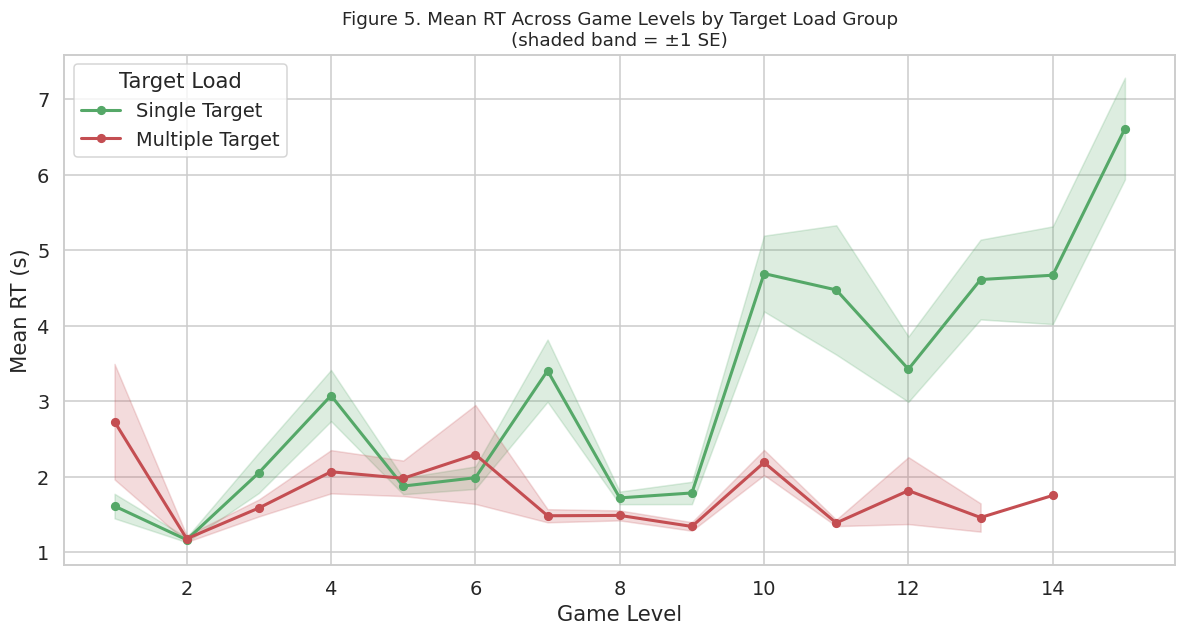

Figure 5 saved.


In [33]:
game_data = trials[trials.modality == 'game'].copy()

if game_data.empty:
    print('No game data available for level effect plot.')
else:
    level_means = (
        game_data
        .groupby(['target_load', 'trial_num'])
        .agg(RT_M = ('RT', 'mean'), RT_SE = ('RT', 'sem'))
        .reset_index()
        .rename(columns={'trial_num': 'Level'})
    )

    fig, ax = plt.subplots(figsize=(11, 6))

    for load, color in LOAD_PALETTE.items():
        sub = level_means[level_means.target_load == load]
        if sub.empty:
            continue
        ax.plot(sub['Level'], sub['RT_M'], marker='o', color=color,
                linewidth=2, markersize=5, label=load.capitalize() + ' Target')
        ax.fill_between(sub['Level'],
                        sub['RT_M'] - sub['RT_SE'],
                        sub['RT_M'] + sub['RT_SE'],
                        color=color, alpha=0.2)

    ax.set_xlabel('Game Level')
    ax.set_ylabel('Mean RT (s)')
    ax.set_title('Figure 5. Mean RT Across Game Levels by Target Load Group\n'
                 '(shaded band = ±1 SE)', fontsize=12)
    ax.legend(title='Target Load')

    plt.tight_layout()
    plt.savefig('fig5_level_effect.png', bbox_inches='tight')
    plt.show()
    print('Figure 5 saved.')

### 5.6 Target Colour Effect on RT and Accuracy (Lab data only)

`target_col` records the colour in which the target(s) were displayed on each trial.
If colour makes the target more salient (e.g. a red target on a grey background pops out),
we would expect **lower RT and higher accuracy** for that colour compared to others.

This plot shows mean RT and accuracy broken down by target colour, separately for
Single and Multiple conditions. Only lab data is used — the game does not record trial-level colour.

Target colours found in lab data: ['red', 'white']
Trials per colour:
target_load  target_color
multiple     red              80
             white           160
single       red             105
             white           210



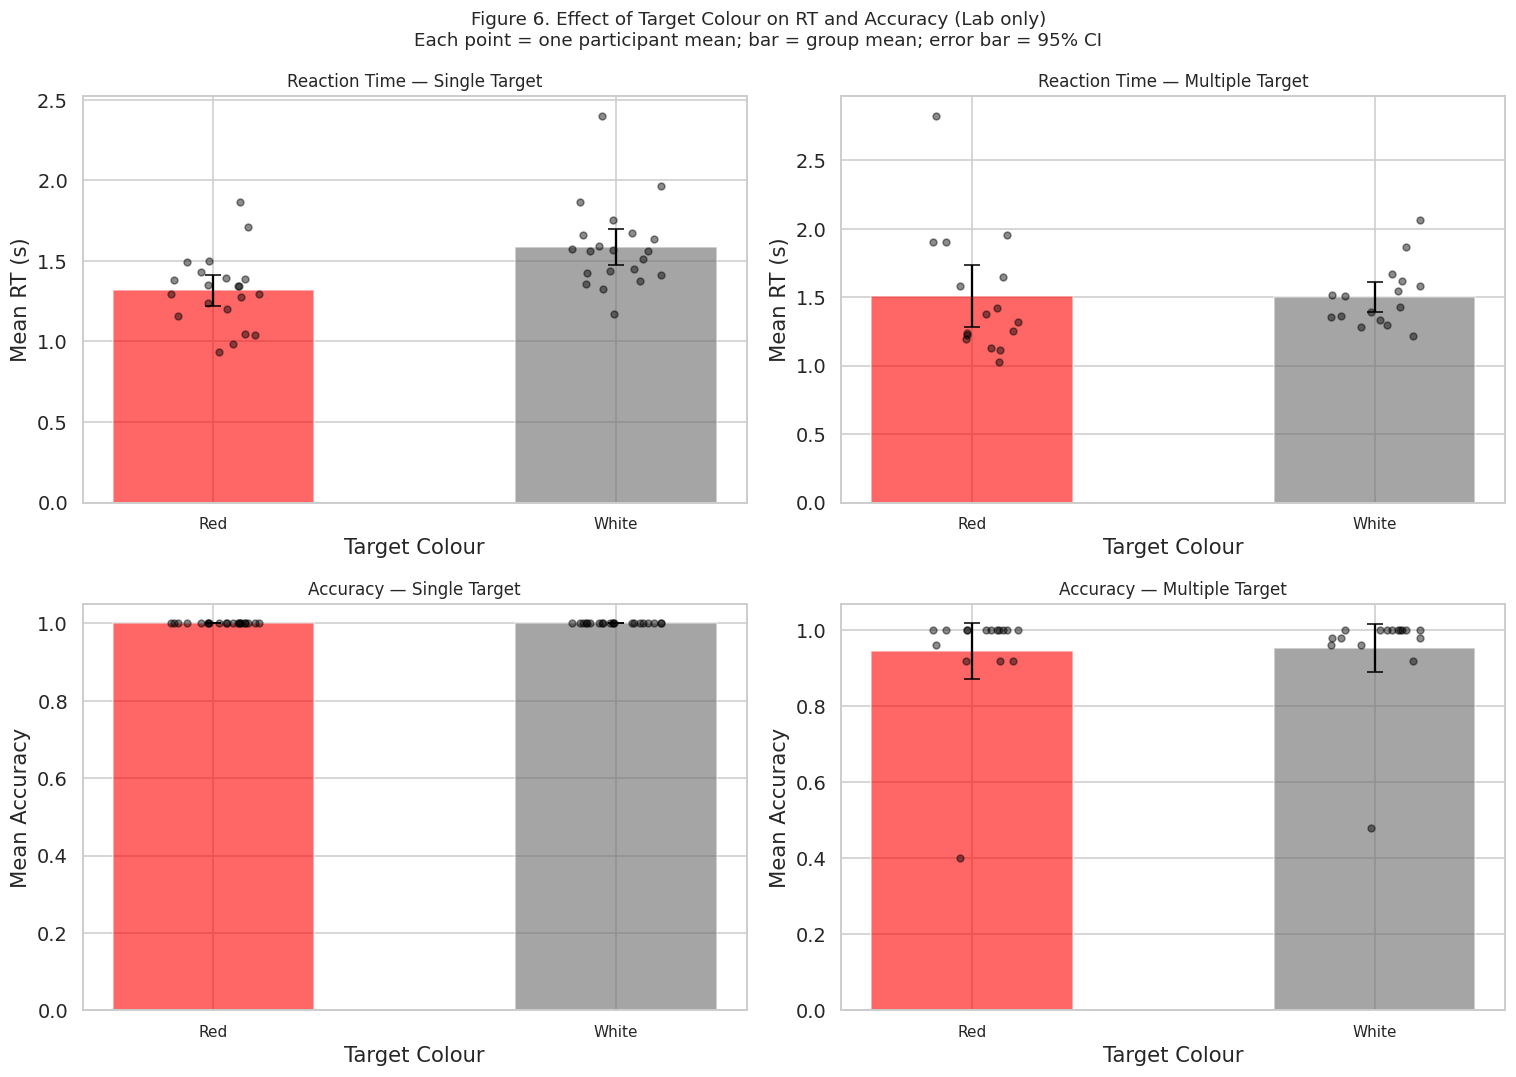

Figure 6 saved.

Mean RT by target colour (lab trials, collapsed across participants):
--------------------------------------------------
  SINGLE TARGET
    red           RT M=1.318s  SD=0.224  Acc M=1.000  n=21
    white         RT M=1.584s  SD=0.262  Acc M=1.000  n=21

  MULTIPLE TARGET
    red           RT M=1.508s  SD=0.461  Acc M=0.945  n=16
    white         RT M=1.504s  SD=0.225  Acc M=0.954  n=16

Statistical test of colour effect on RT (per target_load group):
--------------------------------------------------
  SINGLE: Welch t(40) = -3.536, p = 0.0011, d = -1.091
          Colours: red (M=1.318) vs white (M=1.584)

  MULTIPLE: Welch t(30) = 0.031, p = 0.9759, d = 0.011
          Colours: red (M=1.508) vs white (M=1.504)



In [34]:
lab_trials = trials[(trials.modality == 'lab') & (trials['target_color'] != '')].copy()

if lab_trials.empty or 'target_color' not in lab_trials.columns:
    print('No target_color data available in lab trials.')
else:
    # group by target_load, target_color, participant -> then average across participants
    color_ppt = (
        lab_trials
        .groupby(['target_load', 'target_color', 'participant'])
        .agg(RT_mean=('RT', 'mean'), Acc_mean=('accuracy', 'mean'))
        .reset_index()
    )

    colors_present = sorted(lab_trials['target_color'].unique())
    print(f'Target colours found in lab data: {colors_present}')
    print(f'Trials per colour:')
    print(lab_trials.groupby(['target_load','target_color']).size().to_string())
    print()

    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    fig.suptitle(
        'Figure 6. Effect of Target Colour on RT and Accuracy (Lab only)\n'
        'Each point = one participant mean; bar = group mean; error bar = 95% CI',
        fontsize=12
    )

    dvs = [('RT_mean', 'Mean RT (s)', 'Reaction Time'),
           ('Acc_mean', 'Mean Accuracy', 'Accuracy')]

    for col_idx, (load, load_label) in enumerate([('single', 'Single Target'),
                                                   ('multiple', 'Multiple Target')]):
        sub = color_ppt[color_ppt.target_load == load]
        if sub.empty:
            continue

        for row_idx, (dv, ylabel, dv_label) in enumerate(dvs):
            ax = axes[row_idx][col_idx]

            # bar chart: mean per colour with 95% CI
            color_order = sorted(sub['target_color'].unique())

            # build a colour palette mapping target colour names to display colours
            # if the target_col value IS a valid matplotlib colour, use it directly
            # otherwise fall back to tab10
            import matplotlib.colors as mcolors
            tab10 = plt.cm.tab10.colors
            bar_colors = []
            for i, tc in enumerate(color_order):
                if tc in mcolors.CSS4_COLORS or tc in ['white','red','blue','green',
                                                        'yellow','orange','pink',
                                                        'purple','black','grey','gray',
                                                        'cyan','magenta']:
                    # use a darker version so white is visible on white background
                    c = mcolors.to_rgba(tc)
                    # darken very light colours for visibility
                    brightness = 0.299*c[0] + 0.587*c[1] + 0.114*c[2]
                    bar_colors.append('dimgray' if brightness > 0.85 else tc)
                else:
                    bar_colors.append(tab10[i % 10])

            means = [sub[sub.target_color == tc][dv].mean() for tc in color_order]
            sems  = [sub[sub.target_color == tc][dv].sem()  for tc in color_order]
            ci95  = [1.96 * s for s in sems]

            x = np.arange(len(color_order))
            bars = ax.bar(x, means, color=bar_colors, alpha=0.6,
                          edgecolor='white', width=0.5, zorder=2)
            ax.errorbar(x, means, yerr=ci95, fmt='none',
                        color='black', capsize=5, linewidth=1.5, zorder=3)

            # overlay individual participant dots (jittered)
            rng = np.random.default_rng(42)
            for i, tc in enumerate(color_order):
                pts = sub[sub.target_color == tc][dv].dropna().values
                jitter = rng.uniform(-0.12, 0.12, len(pts))
                ax.scatter(i + jitter, pts, color='black', s=20,
                           alpha=0.45, zorder=4)

            ax.set_xticks(x)
            ax.set_xticklabels([tc.capitalize() for tc in color_order], fontsize=10)
            ax.set_xlabel('Target Colour')
            ax.set_ylabel(ylabel)
            ax.set_title(f'{dv_label} — {load_label}', fontsize=11)

    plt.tight_layout()
    plt.savefig('fig6_target_colour_effect.png', bbox_inches='tight')
    plt.show()
    print('Figure 6 saved.')
    print()

    # ── quick stats: is there a RT difference between colour conditions? ──
    print('Mean RT by target colour (lab trials, collapsed across participants):')
    print('-' * 50)
    for load in ['single', 'multiple']:
        print(f'  {load.upper()} TARGET')
        sub = color_ppt[color_ppt.target_load == load]
        for tc in sorted(sub.target_color.unique()):
            grp = sub[sub.target_color == tc]
            print(f'    {tc:<12}  RT M={grp.RT_mean.mean():.3f}s  '
                  f'SD={grp.RT_mean.std():.3f}  Acc M={grp.Acc_mean.mean():.3f}  n={len(grp)}')
        print()

    # one-way test: if 2 colours exist, independent t-test; if >2, note ANOVA needed
    from scipy.stats import ttest_ind, f_oneway
    print('Statistical test of colour effect on RT (per target_load group):')
    print('-' * 50)
    for load in ['single', 'multiple']:
        sub   = color_ppt[color_ppt.target_load == load]
        cols  = sorted(sub.target_color.unique())
        if len(cols) < 2:
            print(f'  {load.upper()}: only one colour present, no test possible.')
        elif len(cols) == 2:
            g1 = sub[sub.target_color == cols[0]]['RT_mean'].dropna()
            g2 = sub[sub.target_color == cols[1]]['RT_mean'].dropna()
            t, p = ttest_ind(g1, g2, equal_var=False)
            d  = (g1.mean()-g2.mean()) / np.sqrt((g1.std()**2+g2.std()**2)/2)
            print(f'  {load.upper()}: Welch t({len(g1)+len(g2)-2}) = {t:.3f}, '
                  f'p = {p:.4f}, d = {d:.3f}')
            print(f'          Colours: {cols[0]} (M={g1.mean():.3f}) vs '
                  f'{cols[1]} (M={g2.mean():.3f})')
        else:
            groups = [sub[sub.target_color == c]['RT_mean'].dropna().values for c in cols]
            F, p = f_oneway(*groups)
            print(f'  {load.upper()}: one-way ANOVA F = {F:.3f}, p = {p:.4f}')
            print(f'          Colours: {cols}')
            print(f'          (Post-hoc tests needed if significant)')
        print()


## 6. Normality Checks (Shapiro-Wilk)

Shapiro-Wilk is run on participant-level mean RT for each of the four cells.

**Decision rule:**
- p > 0.05 → normality retained → proceed with parametric test (t-test / Pearson r)
- p ≤ 0.05 → normality violated → use non-parametric equivalent (Mann-Whitney U / Wilcoxon / Spearman ρ)

*Note: Shapiro-Wilk has low power with small N. With n = 16 (Multiple group), a non-significant
result does not guarantee normality — it simply means there is insufficient evidence to reject it.*

In [35]:
print('Shapiro-Wilk Normality Test — participant-level mean RT')
print('Bonferroni-corrected alpha = 0.0125  |  per-test alpha = 0.05')
print('-' * 60)
print(f'  {"Condition":<22} {"N":>4}  {"W":>8}  {"p":>8}  {"Normal?":>10}')
print('-' * 60)

normality_results = {}
for load in ['single', 'multiple']:
    for mod in ['lab', 'game']:
        sub = ppt_means[(ppt_means.target_load == load) &
                        (ppt_means.modality    == mod)]['RT_mean'].dropna()
        label = f'{load.capitalize()} / {mod.capitalize()}'
        if len(sub) < 3:
            print(f'  {label:<22}  insufficient data')
            normality_results[(load, mod)] = True   # assume normal if too few obs
            continue
        W, p = shapiro(sub)
        normal = p > 0.05
        normality_results[(load, mod)] = normal
        flag = 'YES' if normal else 'NO *'
        print(f'  {label:<22} {len(sub):>4}  {W:>8.4f}  {p:>8.4f}  {flag:>10}')

print('-' * 60)
print('* p <= 0.05: normality rejected; use non-parametric test for this cell.')

Shapiro-Wilk Normality Test — participant-level mean RT
Bonferroni-corrected alpha = 0.0125  |  per-test alpha = 0.05
------------------------------------------------------------
  Condition                 N         W         p     Normal?
------------------------------------------------------------
  Single / Lab             21    0.8633    0.0073        NO *
  Single / Game            21    0.9054    0.0447        NO *
  Multiple / Lab           16    0.8816    0.0411        NO *
  Multiple / Game          16    0.9262    0.2124         YES
------------------------------------------------------------
* p <= 0.05: normality rejected; use non-parametric test for this cell.


## 7. Inferential Tests

**Multiple comparisons:** 4 t-tests + 4 correlations = 8 tests total.
Bonferroni correction applied separately per family:
- **t-tests:** adjusted α = 0.05 / 4 = **0.0125**
- **Correlations:** adjusted α = 0.05 / 4 = **0.0125**

Effect sizes reported throughout:
- Cohen's *d* for independent t-tests (pooled SD)
- Cohen's *d*_z for paired t-tests (SD of difference scores)
- Pearson *r* for correlations

### 7.1 Load Effect — Independent Samples t-test (RQ2)

**Design rationale:** Target Load is a between-subjects factor. Different participants
are in each group (n = 21 Single, n = 16 Multiple). An independent samples t-test
compares the two independent group means.

**Welch's t-test** is used (equal_var=False) because the groups are of unequal size
and equal variances cannot be assumed without testing.

- H₀: M_Single = M_Multiple (no difference in RT)
- H₁: M_Multiple > M_Single (Multiple Target is harder → slower RT) — **one-tailed**

In [ ]:
print('7.1  Load Effect — Independent Samples t-test (Welch)')
print(f'     Bonferroni-corrected alpha = {ALPHA_CORR}')
print('=' * 68)

for mod in ['lab', 'game']:
    single_rt   = ppt_means[(ppt_means.target_load == 'single')   & (ppt_means.modality == mod)]['RT_mean'].dropna()
    multiple_rt = ppt_means[(ppt_means.target_load == 'multiple') & (ppt_means.modality == mod)]['RT_mean'].dropna()

    if len(single_rt) < 2 or len(multiple_rt) < 2:
        print(f'  {mod.upper()}: insufficient data'); continue

    t_stat, p_two = stats.ttest_ind(multiple_rt, single_rt, equal_var=False)
    p_one = p_two / 2 if t_stat > 0 else 1 - p_two / 2   # one-tailed (Multiple > Single)
    d     = (multiple_rt.mean() - single_rt.mean()) / np.sqrt(
                (single_rt.std()**2 + multiple_rt.std()**2) / 2)
    sig   = 'SIGNIFICANT *' if p_one < ALPHA_CORR else 'not significant'

    print(f'  Modality: {mod.upper()}')
    print(f'    Single   : M = {single_rt.mean():.3f}s,  SD = {single_rt.std():.3f},  n = {len(single_rt)}')
    print(f'    Multiple : M = {multiple_rt.mean():.3f}s,  SD = {multiple_rt.std():.3f},  n = {len(multiple_rt)}')
    print(f'    Welch t = {t_stat:.3f},  p (one-tailed) = {p_one:.4f},  Cohen d = {d:.3f}')
    print(f'    Decision at alpha = {ALPHA_CORR}: {sig}')
    print()

### 7.2 Modality Effect — Paired Samples t-test (RQ3)

**Design rationale:** Modality is a within-subjects factor. The same participant
completed both Lab and Game. Pairing on participant removes between-person variance
and provides a more sensitive test of the modality effect.

- H₀: M_Lab = M_Game
- H₁: M_Lab ≠ M_Game — **two-tailed** (no strong prior for direction of modality effect)

In [ ]:
print('7.2  Modality Effect — Paired Samples t-test')
print(f'     Bonferroni-corrected alpha = {ALPHA_CORR}')
print('=' * 68)

for load in ['single', 'multiple']:
    sub = ppt_wide[ppt_wide['target_load'] == load][['RT_mean_lab', 'RT_mean_game']].dropna()

    if len(sub) < 3:
        print(f'  {load.upper()}: insufficient paired data'); continue

    t_stat, p_two = stats.ttest_rel(sub['RT_mean_lab'], sub['RT_mean_game'])
    diff = sub['RT_mean_lab'] - sub['RT_mean_game']
    dz   = diff.mean() / diff.std()
    sig  = 'SIGNIFICANT *' if p_two < ALPHA_CORR else 'not significant'

    print(f'  Target Load: {load.upper()}')
    print(f'    Lab  : M = {sub.RT_mean_lab.mean():.3f}s,  SD = {sub.RT_mean_lab.std():.3f}')
    print(f'    Game : M = {sub.RT_mean_game.mean():.3f}s,  SD = {sub.RT_mean_game.std():.3f}')
    print(f'    Mean diff (Lab-Game) = {diff.mean():.3f}s,  SD_diff = {diff.std():.3f}')
    print(f'    t({len(sub)-1}) = {t_stat:.3f},  p (two-tailed) = {p_two:.4f},  Cohen dz = {dz:.3f}')
    print(f'    Decision at alpha = {ALPHA_CORR}: {sig}')
    print()

### 7.3 Concurrent Validity — Pearson r (RQ1)

**Design rationale:** To assess concurrent validity, we correlate each participant's
Lab mean with their Game mean. A significant positive r means participants who
attend well in the lab also perform well in the game, supporting validity.

The test is **one-tailed** because the direction is predicted a priori (positive correlation).

Four correlations: RT × Single, RT × Multiple, Accuracy × Single, Accuracy × Multiple.

In [ ]:
print('7.3  Concurrent Validity — Pearson r (one-tailed, positive direction)')
print(f'     Bonferroni-corrected alpha = {ALPHA_CORR}')
print('=' * 68)

validity_tests = [
    ('RT_mean_lab',  'RT_mean_game',  'single',   'RT,       Single Target'),
    ('RT_mean_lab',  'RT_mean_game',  'multiple', 'RT,       Multiple Target'),
    ('Acc_mean_lab', 'Acc_mean_game', 'single',   'Accuracy, Single Target'),
    ('Acc_mean_lab', 'Acc_mean_game', 'multiple', 'Accuracy, Multiple Target'),
]

for xcol, ycol, load, label in validity_tests:
    sub = ppt_wide[ppt_wide['target_load'] == load][[xcol, ycol]].dropna()
    if len(sub) < 3:
        print(f'  {label}: insufficient data'); continue

    r, p_two = pearsonr(sub[xcol], sub[ycol])
    p_one    = p_two / 2 if r > 0 else 1 - p_two / 2
    sig      = 'SIGNIFICANT *' if p_one < ALPHA_CORR else 'not significant'

    print(f'  {label}')
    print(f'    N = {len(sub)},  r = {r:.3f},  p (one-tailed) = {p_one:.4f}')
    print(f'    Decision at alpha = {ALPHA_CORR}: {sig}')
    print()

### 7.4 Level Effect — Pearson r on Level vs. RT (RQ4)

For each Target Load group, correlate Level number with RT (using all game rows,
not participant means, to preserve the trial-level sequence information).

A negative r = RT decreases across levels (learning effect).
A positive r = RT increases (fatigue).
r ≈ 0 = no systematic trend.

In [ ]:
print('7.4  Level Effect — Pearson r (Level number vs. RT within Game)')
print('=' * 68)

game_rows = trials[trials.modality == 'game'].copy()

if game_rows.empty:
    print('No game data available.')
else:
    for load in ['single', 'multiple']:
        sub = game_rows[game_rows.target_load == load][['trial_num', 'RT']].dropna()
        if len(sub) < 5:
            print(f'  {load.upper()}: insufficient data'); continue

        r, p_two = pearsonr(sub['trial_num'], sub['RT'])
        direction = 'learning (RT decreasing)' if r < 0 else 'fatigue (RT increasing)'
        sig       = 'SIGNIFICANT *' if p_two < 0.05 else 'not significant'

        print(f'  {load.upper()} Target Group')
        print(f'    N (game rows) = {len(sub)},  r = {r:.3f},  p = {p_two:.4f}')
        print(f'    Direction: {direction}')
        print(f'    Decision at alpha = 0.05: {sig}')
        print()

## 8. Summary of All Test Results

Consolidated table of all inferential tests with effect sizes and significance decisions.

In [ ]:
print('=' * 75)
print('SUMMARY OF INFERENTIAL TESTS')
print(f'Bonferroni-corrected alpha = {ALPHA_CORR}  (per family of 4 tests)')
print('=' * 75)

summary = [
    ('7.1', 'Load Effect (Lab)',     'Indep. t-test', 'RQ2', 'one-tail'),
    ('7.1', 'Load Effect (Game)',    'Indep. t-test', 'RQ2', 'one-tail'),
    ('7.2', 'Modality Effect (Single)',   'Paired t-test', 'RQ3', 'two-tail'),
    ('7.2', 'Modality Effect (Multiple)', 'Paired t-test', 'RQ3', 'two-tail'),
    ('7.3', 'Validity RT Single',    'Pearson r',     'RQ1', 'one-tail'),
    ('7.3', 'Validity RT Multiple',  'Pearson r',     'RQ1', 'one-tail'),
    ('7.3', 'Validity Acc Single',   'Pearson r',     'RQ1', 'one-tail'),
    ('7.3', 'Validity Acc Multiple', 'Pearson r',     'RQ1', 'one-tail'),
    ('7.4', 'Level Effect Single',   'Pearson r',     'RQ4', 'two-tail'),
    ('7.4', 'Level Effect Multiple', 'Pearson r',     'RQ4', 'two-tail'),
]

print(f'  {"Sec":<5} {"Test":<28} {"Method":<16} {"RQ":<5} {"Tail":<9}')
print(f'  {"":5} {"":28} {"Fill in p and significance from cells 7.1-7.4 above":}')
print('-' * 75)
for sec, test, method, rq, tail in summary:
    print(f'  {sec:<5} {test:<28} {method:<16} {rq:<5} {tail}')
print()
print('Figures saved: fig1_rt_distributions.png, fig2_accuracy_distributions.png,')
print('               fig3_means_ci.png, fig4_validity_scatter.png, fig5_level_effect.png')